In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install onnxruntime opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 66.4 MB/s eta 0:00:00


In [3]:
import os, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [4]:
CONFIG = {
    "data_dir":        "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_crop",
    "input_size":      224,
    "batch_size":      32,
    "epochs":          50,
    "patience":        5,
    "min_delta":       1e-4,
    "lr":              1e-4,
    "weight_decay":    1e-4,
    "label_smoothing": 0.1,
    "test_split":      0.20,   # 20% test
    "val_split":       0.125,  # 10% val (= 0.125 của 80% còn lại)
    "num_workers":     2,
    "save_path":       "/content/drive/MyDrive/best_mobilenetv3_antispoof224x224.pth",
    "seed":            42,
}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [5]:
# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang dùng: {device}")

Đang dùng: cuda


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Transforms
# ══════════════════════════════════════════════════════════════════════════════
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["input_size"], CONFIG["input_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["input_size"], CONFIG["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print("Transforms sẵn sàng.")


Transforms sẵn sàng.


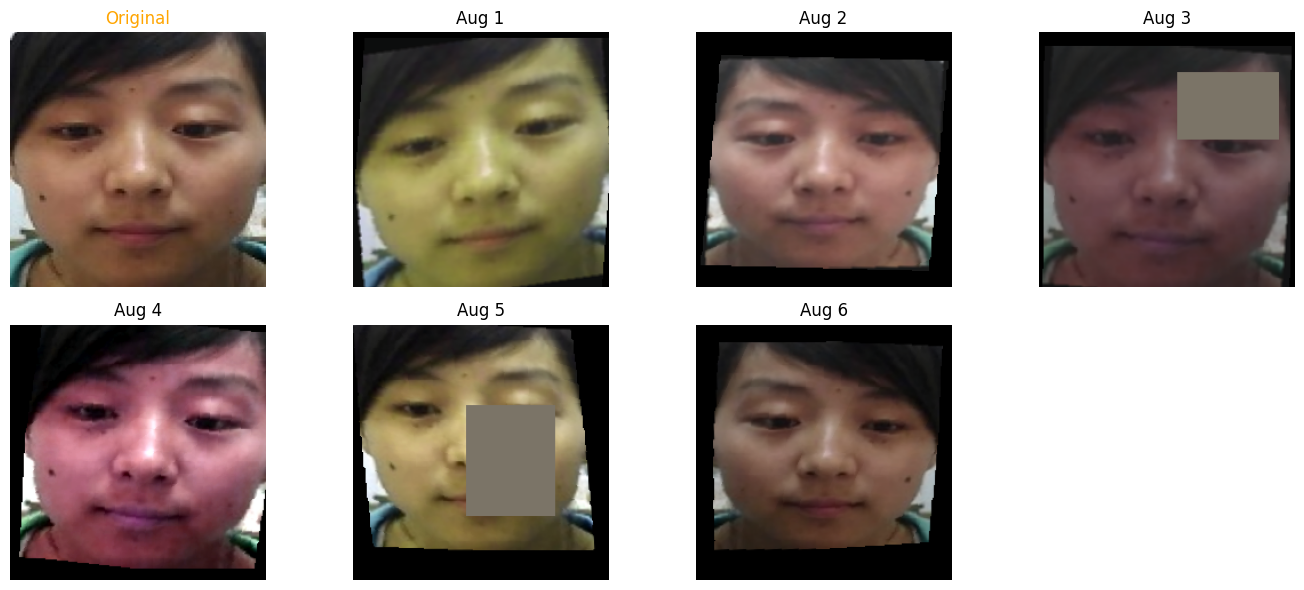

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Visualize augmentation
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from PIL import Image

def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img  = std * img + mean          # unnormalize đúng cách
    img  = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")

img_path = "/content/drive/MyDrive/Đồ Án Tốt Nghiệp/data_crop112x112/face_real_crop/000988.jpg"
image    = Image.open(img_path).convert("RGB")

fig = plt.figure(figsize=(14, 6))

ax = plt.subplot(2, 4, 1)
plt.imshow(image)
plt.title("Original", color="orange")
plt.axis("off")

for i in range(6):
    augmented = train_transform(image)
    ax = plt.subplot(2, 4, i + 2)
    imshow(augmented, title=f"Aug {i+1}")

plt.tight_layout()
plt.show()

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Dataset
# ══════════════════════════════════════════════════════════════════════════════
def build_datasets(data_dir):
    full_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

    print(f"Tổng số ảnh : {len(full_dataset)}")
    print(f"Classes     : {full_dataset.classes}  →  {full_dataset.class_to_idx}")

    # ── Kiểm tra thứ tự class (quan trọng cho FAR/FRR) ──────────────────────
    assert full_dataset.class_to_idx.get("face_fake_crop") == 0 and \
           full_dataset.class_to_idx.get("face_real_crop") == 1, \
        "❌ Class index không đúng thứ tự mong đợi! Kiểm tra lại tên folder."

    targets     = np.array(full_dataset.targets)
    all_idx     = np.arange(len(full_dataset))

    # ── Tách Test 20% ────────────────────────────────────────────────────────
    train_val_idx, test_idx = train_test_split(
        all_idx,
        test_size=CONFIG["test_split"],
        stratify=targets,
        random_state=CONFIG["seed"],
    )

    # ── Tách Val 10% (từ 80% train_val) ─────────────────────────────────────
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=CONFIG["val_split"],
        stratify=targets[train_val_idx],
        random_state=CONFIG["seed"],
    )

    def count_class(indices, name):
        labels = targets[indices]
        real   = np.sum(labels == full_dataset.class_to_idx["face_real_crop"])
        fake   = np.sum(labels == full_dataset.class_to_idx["face_fake_crop"])
        print(f"  {name:8s}: {len(indices):6d} ảnh | REAL: {real} | FAKE: {fake}")

    print("\nPHÂN BỐ DATASET (70 / 10 / 20)")
    count_class(train_idx, "Train")
    count_class(val_idx,   "Val")
    count_class(test_idx,  "Test")

    # ── Dataset objects ──────────────────────────────────────────────────────
    train_base = datasets.ImageFolder(root=data_dir, transform=train_transform)
    val_base   = datasets.ImageFolder(root=data_dir, transform=val_transform)
    test_base  = datasets.ImageFolder(root=data_dir, transform=val_transform)

    # ── Weighted sampler để xử lý class imbalance ────────────────────────────
    train_targets    = targets[train_idx]
    class_counts     = np.bincount(train_targets)
    class_weights    = 1.0 / class_counts.astype(float)
    sample_weights   = class_weights[train_targets]
    sampler          = WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float),
        num_samples = len(train_idx),
        replacement = True,
    )
    print(f"\n  Class weights  → FAKE: {class_weights[0]:.4f} | REAL: {class_weights[1]:.4f}")
    print("  WeightedRandomSampler sẵn sàng.")

    return (
        Subset(train_base, train_idx),
        Subset(val_base,   val_idx),
        Subset(test_base,  test_idx),
        full_dataset.class_to_idx,
        sampler,
    )

train_dataset, val_dataset, test_dataset, class_to_idx, train_sampler = \
    build_datasets(CONFIG["data_dir"])

REAL_IDX = class_to_idx["face_real_crop"]
FAKE_IDX = class_to_idx["face_fake_crop"]
print(f"\nREAL index = {REAL_IDX}  |  FAKE index = {FAKE_IDX}")

Tổng số ảnh : 17348
Classes     : ['face_fake_crop', 'face_real_crop']  →  {'face_fake_crop': 0, 'face_real_crop': 1}

PHÂN BỐ DATASET (70 / 10 / 20)
  Train   :  12143 ảnh | REAL: 4274 | FAKE: 7869
  Val     :   1735 ảnh | REAL: 611 | FAKE: 1124
  Test    :   3470 ảnh | REAL: 1221 | FAKE: 2249

  Class weights  → FAKE: 0.0001 | REAL: 0.0002
  WeightedRandomSampler sẵn sàng.

REAL index = 1  |  FAKE index = 0


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Model
# ══════════════════════════════════════════════════════════════════════════════
def build_model(num_classes=2):
    model       = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    for p in model.parameters():
        p.requires_grad = True
    return model.to(device)

model       = build_model(num_classes=2)
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_p:,}")
print(f"Trainable params : {trainable_p:,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 64.7MB/s]


Total params     : 1,519,906
Trainable params : 1,519,906


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Train / Validate helpers
# ══════════════════════════════════════════════════════════════════════════════
def train_one_epoch(model, loader, criterion, optimizer, epoch, total):
    model.train()
    running_loss, correct, n = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"  [Train] E{epoch:>3d}/{total}", leave=False,
                bar_format="{l_bar}{bar:28}{r_bar}")
    for images, labels in pbar:
        images  = images.to(device, non_blocking=True)
        labels  = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        n            += images.size(0)
        pbar.set_postfix(loss=f"{running_loss/n:.4f}", acc=f"{correct/n*100:.2f}%")
    return running_loss / n, correct / n


@torch.no_grad()
def validate(model, loader, criterion, epoch, total):
    model.eval()
    running_loss, correct, n = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"  [Val  ] E{epoch:>3d}/{total}", leave=False,
                bar_format="{l_bar}{bar:28}{r_bar}")
    for images, labels in pbar:
        images  = images.to(device, non_blocking=True)
        labels  = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        n            += images.size(0)
        pbar.set_postfix(loss=f"{running_loss/n:.4f}", acc=f"{correct/n*100:.2f}%")
    return running_loss / n, correct / n

print("Hàm train/validate sẵn sàng.")

Hàm train/validate sẵn sàng.


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — DataLoaders
# ══════════════════════════════════════════════════════════════════════════════
train_loader = DataLoader(
    train_dataset,
    batch_size  = CONFIG["batch_size"],
    sampler     = train_sampler,       # dùng sampler thay shuffle để xử lý imbalance
    num_workers = CONFIG["num_workers"],
    pin_memory  = torch.cuda.is_available(),
    drop_last   = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = CONFIG["num_workers"],
    pin_memory  = torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = False,
    num_workers = CONFIG["num_workers"],
    pin_memory  = torch.cuda.is_available(),
)
print("DataLoaders sẵn sàng.")

DataLoaders sẵn sàng.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Optimizer / Scheduler / Criterion
# ══════════════════════════════════════════════════════════════════════════════
criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])
optimizer = optim.AdamW(
    model.parameters(),
    lr           = CONFIG["lr"],
    weight_decay = CONFIG["weight_decay"],
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = CONFIG["epochs"],
    eta_min = CONFIG["lr"] * 0.01,
)
print("Optimizer / Scheduler / Criterion sẵn sàng.")

Optimizer / Scheduler / Criterion sẵn sàng.


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Training loop
# ══════════════════════════════════════════════════════════════════════════════
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc  = 0.0
best_val_loss = math.inf
no_improve    = 0
total_epochs  = CONFIG["epochs"]
patience      = CONFIG["patience"]
min_delta     = CONFIG["min_delta"]

print("=" * 72)
print(f"  Training | tối đa {total_epochs} epochs  |  Early stopping patience = {patience}  |  min_delta = {min_delta}")
print(f"  Optimizer : AdamW  lr={CONFIG['lr']}  wd={CONFIG['weight_decay']}")
print(f"  Scheduler : CosineAnnealingLR  T_max={total_epochs}  eta_min={CONFIG['lr']*0.01:.1e}")
print(f"  Checkpoint: {CONFIG['save_path']}")
print("=" * 72)

for epoch in range(1, total_epochs + 1):
    t0 = time.time()
    lr = scheduler.get_last_lr()[0]

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, epoch, total_epochs)
    val_loss,   val_acc   = validate(model, val_loader, criterion, epoch, total_epochs)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - t0

    improved = (
        val_acc > best_val_acc + min_delta or
        (abs(val_acc - best_val_acc) <= min_delta and val_loss < best_val_loss)
    )

    if improved:
        best_val_acc  = val_acc
        best_val_loss = val_loss
        no_improve    = 0
        torch.save({
            "epoch":           epoch,
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc":         best_val_acc,
            "val_loss":        best_val_loss,
            "class_to_idx":    class_to_idx,
            "config":          CONFIG,
        }, CONFIG["save_path"])
        flag = "  ✅ best saved"
    else:
        no_improve += 1
        flag = f"  ⏸ no improve {no_improve}/{patience}"

    print(
        f"\n  {'━'*68}\n"
        f"  Epoch {epoch:>3d}/{total_epochs}  "
        f"LR={lr:.2e}  ({elapsed:.1f}s)\n"
        f"  {'─'*68}\n"
        f"  {'Metric':<14} {'Train':>12} {'Val':>12}\n"
        f"  {'─'*68}\n"
        f"  {'Loss':<14} {train_loss:>12.4f} {val_loss:>12.4f}\n"
        f"  {'Accuracy':<14} {train_acc*100:>11.2f}% {val_acc*100:>11.2f}%\n"
        f"  {'━'*68}{flag}"
    )

    if no_improve >= patience:
        print(f"\n  🛑 Early stopping: {patience} epoch liên tiếp không cải thiện.")
        break

print("\n" + "=" * 72)
print("  ✅  Training hoàn tất!")
print(f"  Dừng tại epoch       : {epoch}/{total_epochs}")
print(f"  Best val Accuracy    : {best_val_acc*100:.2f}%")
print(f"  Best val Loss        : {best_val_loss:.4f}")
print(f"  Checkpoint           : {CONFIG['save_path']}")
print("=" * 72)

  Training | tối đa 50 epochs  |  Early stopping patience = 5  |  min_delta = 0.0001
  Optimizer : AdamW  lr=0.0001  wd=0.0001
  Scheduler : CosineAnnealingLR  T_max=50  eta_min=1.0e-06
  Checkpoint: /content/drive/MyDrive/best_mobilenetv3_antispoof224x224.pth



  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch   1/50  LR=1.00e-04  (2457.5s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.3731       0.2938
  Accuracy             89.19%       94.99%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ✅ best saved



  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch   2/50  LR=9.99e-05  (832.3s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.3024       0.2590
  Accuracy             94.11%       96.20%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ✅ best saved



  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch   3/50  LR=9.96e-05  (414.5s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.2816       0.2547
  Accuracy             95.45%       96.89%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ✅ best saved



  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch   4/50  LR=9.91e-05  (295.1s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.2657       0.2460
  Accuracy             96.30%       97.41%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ✅ best saved


...


  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch  11/50  LR=9.05e-05  (188.6s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.2363       0.2411
  Accuracy             98.03%       97.98%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ⏸ no improve 1/5



  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch  12/50  LR=8.86e-05  (189.1s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.2333       0.2367
  Accuracy             98.25%       97.64%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ⏸ no improve 2/5



  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch  13/50  LR=8.66e-05  (188.4s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.2291       0.2384
  Accuracy             98.60%       98.04%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ⏸ no improve 3/5



  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch  14/50  LR=8.44e-05  (187.6s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.2284       0.2435
  Accuracy             98.47%       97.41%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ⏸ no improve 4/5



  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch  15/50  LR=8.21e-05  (186.4s)
  ────────────────────────────────────────────────────────────────────
  Metric                Train          Val
  ────────────────────────────────────────────────────────────────────
  Loss                 0.2269       0.2361
  Accuracy             98.64%       97.81%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  ⏸ no improve 5/5

  🛑 Early stopping: 5 epoch liên tiếp không cải thiện.

  ✅  Training hoàn tất!
  Dừng tại epoch       : 15/50
  Best val Accuracy    : 98.16%
  Best val Loss        : 0.2364
  Checkpoint           : /content/drive/MyDrive/best_mobilenetv3_antispoof224x224.pth


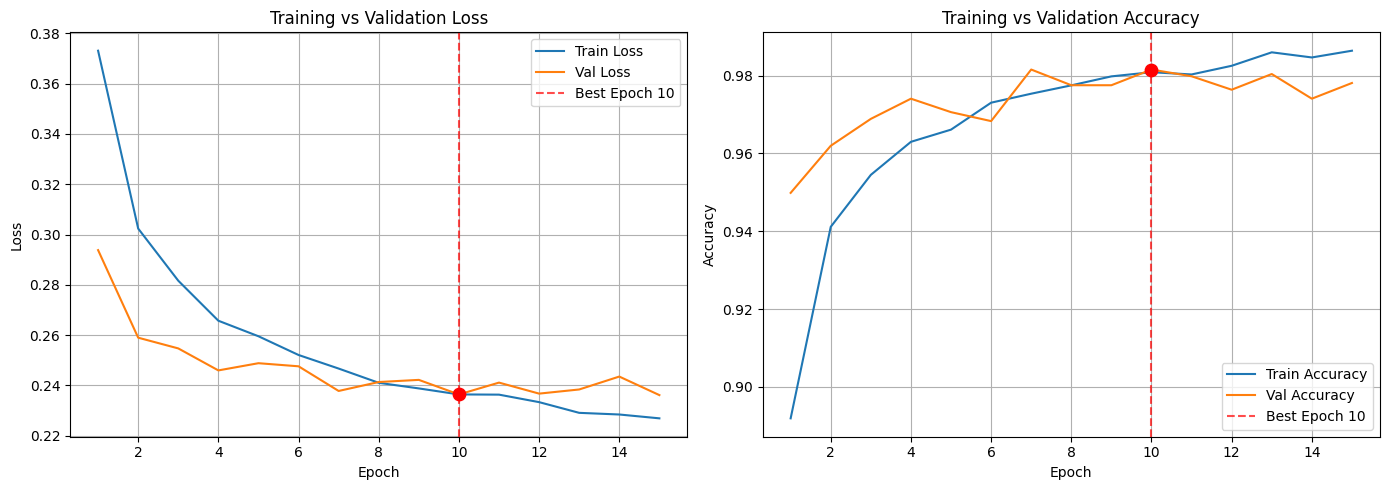

🏆 BEST MODEL
  Epoch    : 10
  Val Acc  : 98.16%
  Val Loss : 0.2364


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Plot training history
# ══════════════════════════════════════════════════════════════════════════════
_ckpt         = torch.load(CONFIG["save_path"], map_location="cpu")
best_epoch    = _ckpt["epoch"]
best_val_acc  = _ckpt["val_acc"]
best_val_loss = _ckpt["val_loss"]

epochs_range  = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"],   label="Val Loss")
plt.scatter(best_epoch, best_val_loss, color="red", s=80, zorder=5)
plt.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.7,
            label=f"Best Epoch {best_epoch}")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"],   label="Val Accuracy")
plt.scatter(best_epoch, best_val_acc, color="red", s=80, zorder=5)
plt.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.7,
            label=f"Best Epoch {best_epoch}")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

print("=" * 50)
print(f"🏆 BEST MODEL")
print(f"  Epoch    : {best_epoch}")
print(f"  Val Acc  : {best_val_acc*100:.2f}%")
print(f"  Val Loss : {best_val_loss:.4f}")
print("=" * 50)

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Test evaluation  (FIX: load best checkpoint trước)
# ══════════════════════════════════════════════════════════════════════════════
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    roc_auc_score, f1_score, roc_curve,
)

# ── ✅ FIX: Load best checkpoint ─────────────────────────────────────────────
checkpoint = torch.load(CONFIG["save_path"], map_location=device)
model.load_state_dict(checkpoint["model_state"])
print(f"✅ Loaded best model từ epoch {checkpoint['epoch']} "
      f"(val_acc={checkpoint['val_acc']*100:.2f}%)")
model.eval()

all_preds  = []
all_labels = []
all_probs  = []   # lưu prob của class REAL để tính AUC
test_loss  = 0.0
total      = 0

criterion_test = nn.CrossEntropyLoss()

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        labels  = labels.to(device)
        outputs = model(images)
        loss    = criterion_test(outputs, labels)

        test_loss += loss.item() * images.size(0)
        total     += labels.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, REAL_IDX].cpu().numpy())   # prob REAL

# ── Metrics ──────────────────────────────────────────────────────────────────
test_loss = test_loss / total
test_acc  = accuracy_score(all_labels, all_preds)

# FAKE=0, REAL=1  →  positive class = REAL (1)
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()

FAR = fp / (fp + tn + 1e-8)   # Fake bị nhận nhầm là Real
FRR = fn / (fn + tp + 1e-8)   # Real bị nhận nhầm là Fake
F1  = f1_score(all_labels, all_preds, pos_label=REAL_IDX)
AUC = roc_auc_score(all_labels, all_probs)

print("\n" + "=" * 60)
print("📊 TEST SET RESULTS")
print("=" * 60)
print(f"  Test Loss        : {test_loss:.4f}")
print(f"  Test Accuracy    : {test_acc*100:.2f}%")
print(f"  F1-Score (Real)  : {F1:.4f}")
print(f"  AUC-ROC          : {AUC:.4f}")
print("-" * 60)
print(f"  True  Positive   : {tp}")
print(f"  True  Negative   : {tn}")
print(f"  False Positive   : {fp}  (Fake nhận nhầm → Real)")
print(f"  False Negative   : {fn}  (Real nhận nhầm → Fake)")
print("-" * 60)
print(f"  FAR (Fake Accept): {FAR*100:.2f}%")
print(f"  FRR (Real Reject): {FRR*100:.2f}%")
print("=" * 60)

✅ Loaded best model từ epoch 10 (val_acc=98.16%)

📊 TEST SET RESULTS
  Test Loss        : 0.0991
  Test Accuracy    : 97.69%
  F1-Score (Real)  : 0.9673
  AUC-ROC          : 0.9971
------------------------------------------------------------
  True  Positive   : 1184
  True  Negative   : 2206
  False Positive   : 43  (Fake nhận nhầm → Real)
  False Negative   : 37  (Real nhận nhầm → Fake)
------------------------------------------------------------
  FAR (Fake Accept): 1.91%
  FRR (Real Reject): 3.03%


In [19]:
# ── Tìm threshold tối ưu (Youden's Index) ────────────────────────────────────
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=REAL_IDX)
youden_idx  = np.argmax(tpr - fpr)
best_thresh = thresholds[youden_idx]
print(f"Threshold tối ưu: {best_thresh:.4f}")

# ── Dự đoán lại với threshold mới ────────────────────────────────────────────
all_preds_new = (np.array(all_probs) >= best_thresh).astype(int)

tn2, fp2, fn2, tp2 = confusion_matrix(all_labels, all_preds_new).ravel()
FAR2 = fp2 / (fp2 + tn2 + 1e-8)
FRR2 = fn2 / (fn2 + tp2 + 1e-8)

print(f"\nSo sánh threshold 0.5  vs  {best_thresh:.4f}:")
print(f"{'':20s} {'Threshold 0.5':>15} {'Threshold tối ưu':>18}")
print(f"{'FAR':20s} {FAR*100:>14.2f}% {FAR2*100:>17.2f}%")
print(f"{'FRR':20s} {FRR*100:>14.2f}% {FRR2*100:>17.2f}%")
print(f"{'Accuracy':20s} {test_acc*100:>14.2f}% {accuracy_score(all_labels, all_preds_new)*100:>17.2f}%")

Threshold tối ưu: 0.4362

So sánh threshold 0.5  vs  0.4362:
                       Threshold 0.5   Threshold tối ưu
FAR                            1.91%              2.09%
FRR                            3.03%              2.38%
Accuracy                      97.69%             97.81%


In [22]:
checkpoint["best_threshold"] = float(best_thresh)
torch.save(checkpoint, CONFIG["save_path"])
print(f"✅ Đã lưu threshold {best_thresh:.4f} vào checkpoint")

✅ Đã lưu threshold 0.4362 vào checkpoint


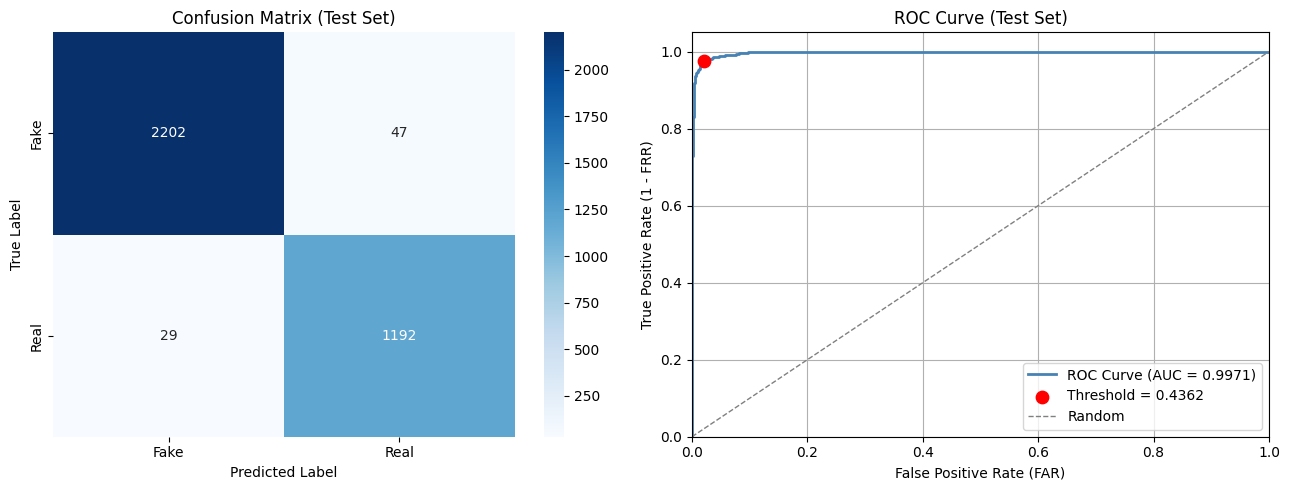

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Plots: Confusion Matrix + ROC Curve
# ══════════════════════════════════════════════════════════════════════════════
cm = confusion_matrix(all_labels, all_preds_new)
fpr, tpr, _ = roc_curve(all_labels, all_probs, pos_label=REAL_IDX)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Confusion Matrix ─────────────────────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            ax=axes[0])
axes[0].set_title("Confusion Matrix (Test Set)")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ── ROC Curve ────────────────────────────────────────────────────────────────
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC Curve (AUC = {AUC:.4f})")
axes[1].scatter(fpr[youden_idx], tpr[youden_idx],
                color="red", s=80, zorder=5,
                label=f"Threshold = {best_thresh:.4f}")
axes[1].legend(loc="lower right")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (FAR)")
axes[1].set_ylabel("True Positive Rate (1 - FRR)")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()